# Phase 8: All Visualizations

**Goal:** Create publication-ready visualizations


## Setup

In [1]:
#!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
import os

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

print('='*80)
print('PHASE 8: VISUALIZATIONS')
print('='*80)

PHASE 8: VISUALIZATIONS


## Load Data and Create Output Folders

In [3]:
# Create folders
os.makedirs('Output/figures', exist_ok=True)
os.makedirs('Output/figures/wordclouds', exist_ok=True)
print('✓ Created output folders')

# Load data
df = pd.read_csv('Output/phase7_comments_with_context.csv')
stats = pd.read_csv('Output/phase6_topic_toxicity_statistics.csv')

print(f'✓ Loaded {len(df):,} comments')
print(f'✓ Loaded statistics for {len(stats)} topics')

✓ Created output folders
✓ Loaded 4,992 comments
✓ Loaded statistics for 47 topics


---
## Visualization 1: Topic-Toxicity Heatmap
---

Creating topic-toxicity heatmap...
✓ SAVED: Output/figures/phase8_topic_toxicity_heatmap.png


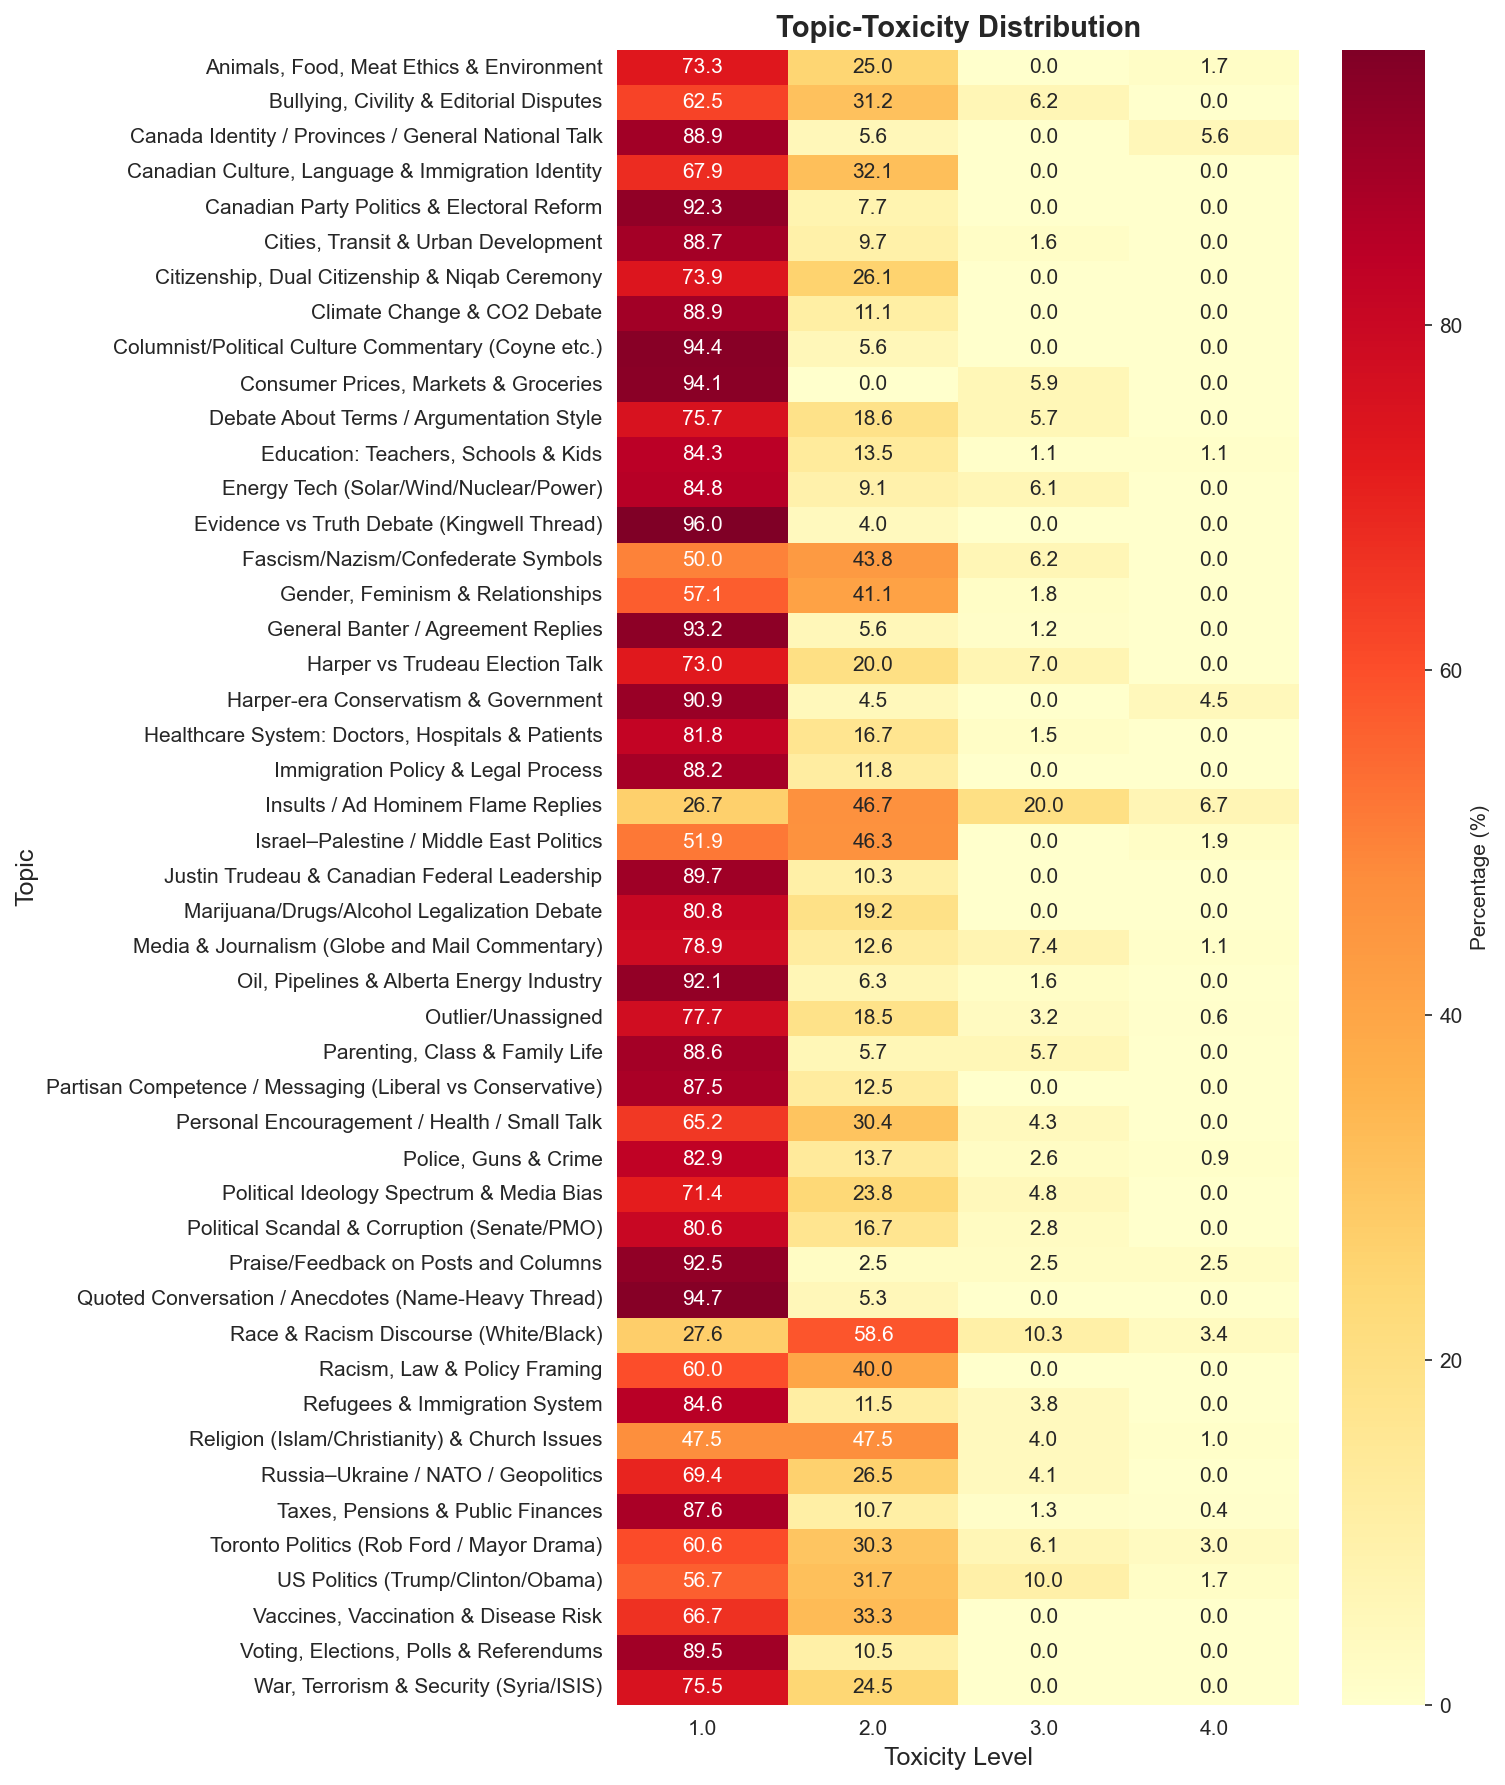

In [4]:
print('Creating topic-toxicity heatmap...')

heatmap_data = pd.crosstab(
    df['bertopic_topic_label'],
    df['toxicity_level'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Percentage (%)'})
plt.title('Topic-Toxicity Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Toxicity Level', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.tight_layout()
plt.savefig('Output/figures/phase8_topic_toxicity_heatmap.png', dpi=300, bbox_inches='tight')
print('✓ SAVED: Output/figures/phase8_topic_toxicity_heatmap.png')
plt.show()

---
## Visualization 2: Mean Toxicity by Topic
---

Creating toxicity by topic bar chart...
✓ SAVED: Output/figures/phase8_toxicity_by_topic_barplot.png


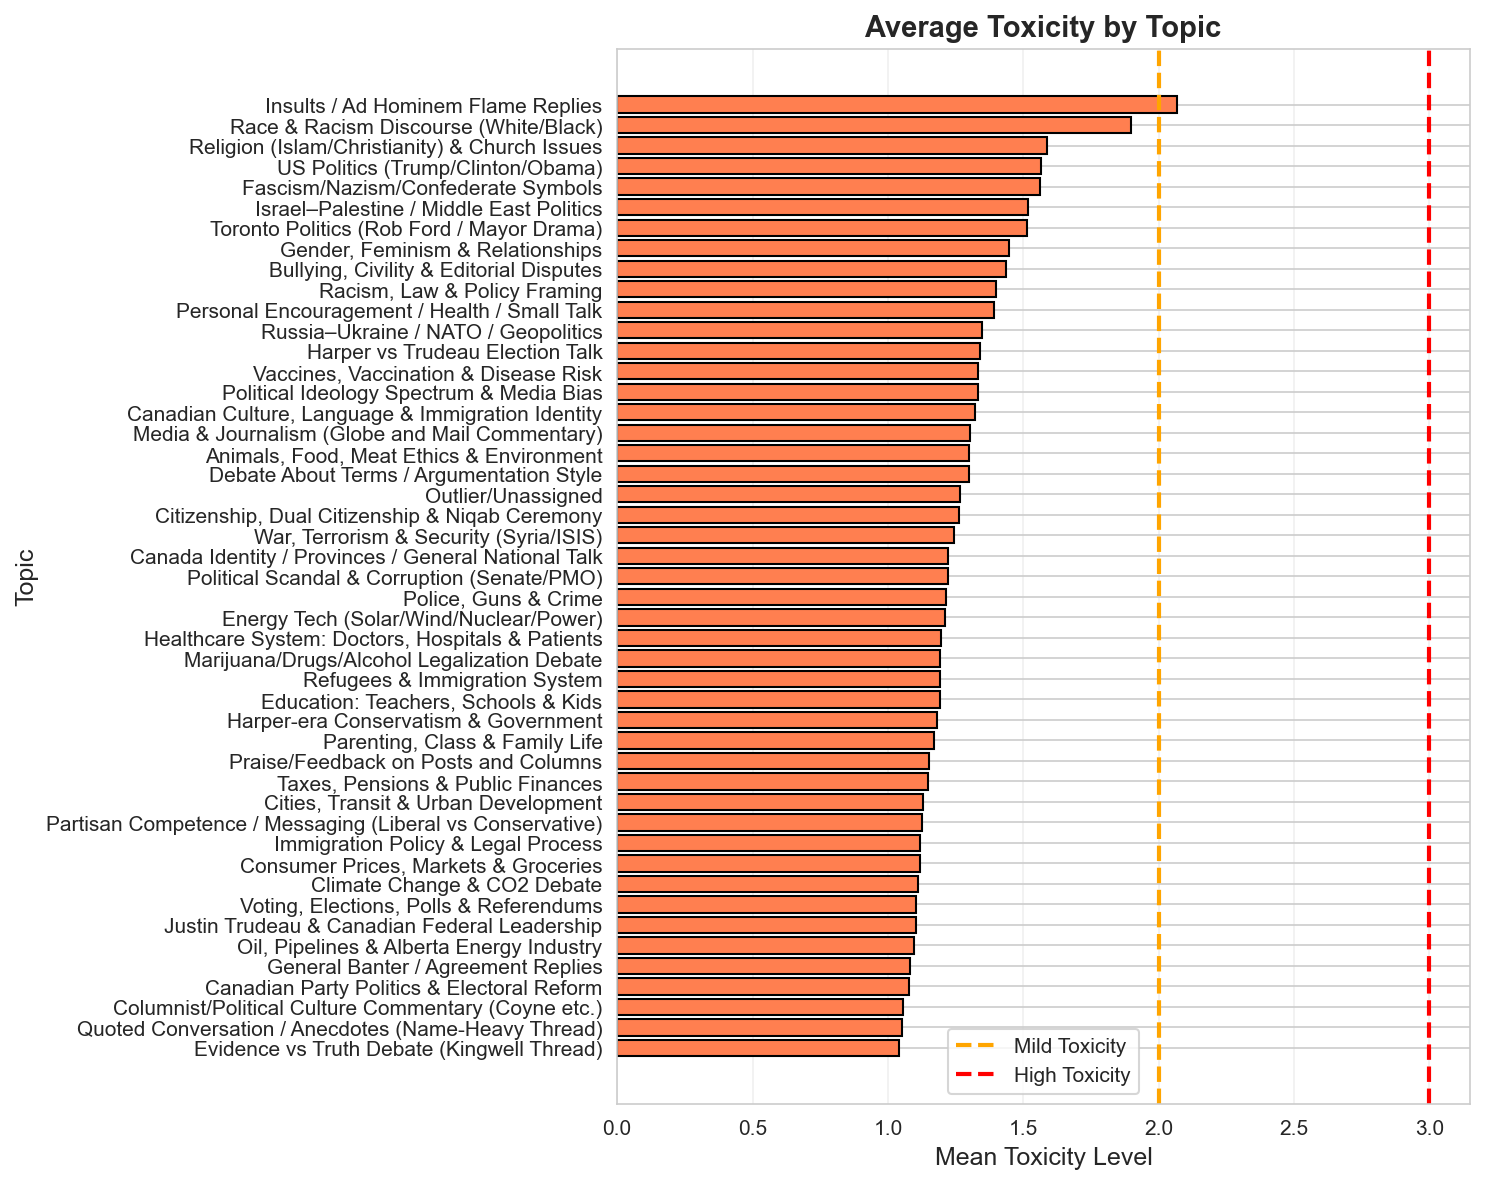

In [5]:
print('Creating toxicity by topic bar chart...')

stats_sorted = stats.sort_values('mean_toxicity', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(stats_sorted['bertopic_topic_label'], stats_sorted['mean_toxicity'], 
         color='coral', edgecolor='black')
plt.xlabel('Mean Toxicity Level', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.title('Average Toxicity by Topic', fontsize=14, fontweight='bold')
plt.axvline(x=2.0, color='orange', linestyle='--', label='Mild Toxicity', linewidth=2)
plt.axvline(x=3.0, color='red', linestyle='--', label='High Toxicity', linewidth=2)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Output/figures/phase8_toxicity_by_topic_barplot.png', dpi=300, bbox_inches='tight')
print('✓ SAVED: Output/figures/phase8_toxicity_by_topic_barplot.png')
plt.show()

---
## Visualization 3: Topic Distribution
---

Creating topic distribution chart...
✓ SAVED: Output/figures/phase8_topic_distribution.png


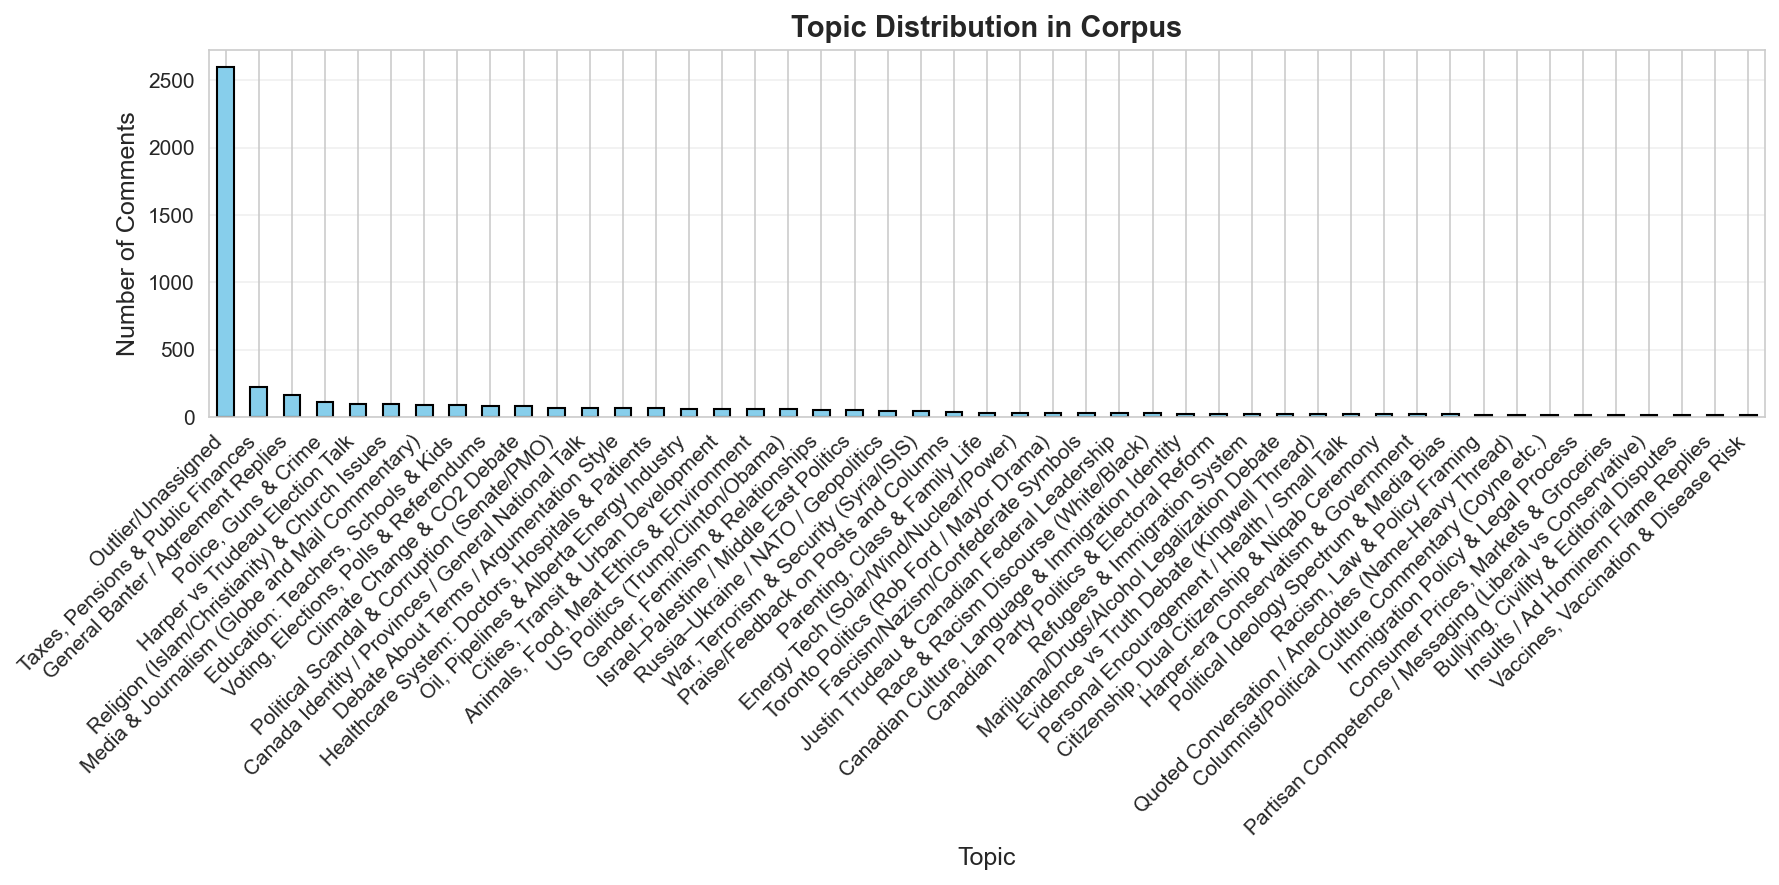

In [6]:
print('Creating topic distribution chart...')

topic_counts = df['bertopic_topic_label'].value_counts()

plt.figure(figsize=(12, 6))
topic_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Topic Distribution in Corpus', fontsize=14, fontweight='bold')
plt.xlabel('Topic', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Output/figures/phase8_topic_distribution.png', dpi=300, bbox_inches='tight')
print('✓ SAVED: Output/figures/phase8_topic_distribution.png')
plt.show()

---
## Visualization 4: Word Clouds per Topic
---

In [7]:
print('Creating word clouds per topic...')

for i, topic in enumerate(df['bertopic_topic_label'].unique()[:5]):  # First 5 topics
    topic_comments = df[df['bertopic_topic_label'] == topic]['comment_text']
    text = ' '.join(topic_comments.astype(str))
    
    wordcloud = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud: {topic}', fontsize=14, fontweight='bold')
    
    filename = f'Output/figures/wordclouds/phase8_wordcloud_{i+1}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'  ✓ Created wordcloud {i+1}/5')

print('✓ SAVED: Word clouds in Output/figures/wordclouds/')

Creating word clouds per topic...
  ✓ Created wordcloud 1/5
  ✓ Created wordcloud 2/5
  ✓ Created wordcloud 3/5
  ✓ Created wordcloud 4/5
  ✓ Created wordcloud 5/5
✓ SAVED: Word clouds in Output/figures/wordclouds/


---
## Visualization 5: Topic-Context Interaction Heatmap
---

Creating topic-context interaction heatmap...
✓ SAVED: Output/figures/phase8_topic_context_heatmap.png


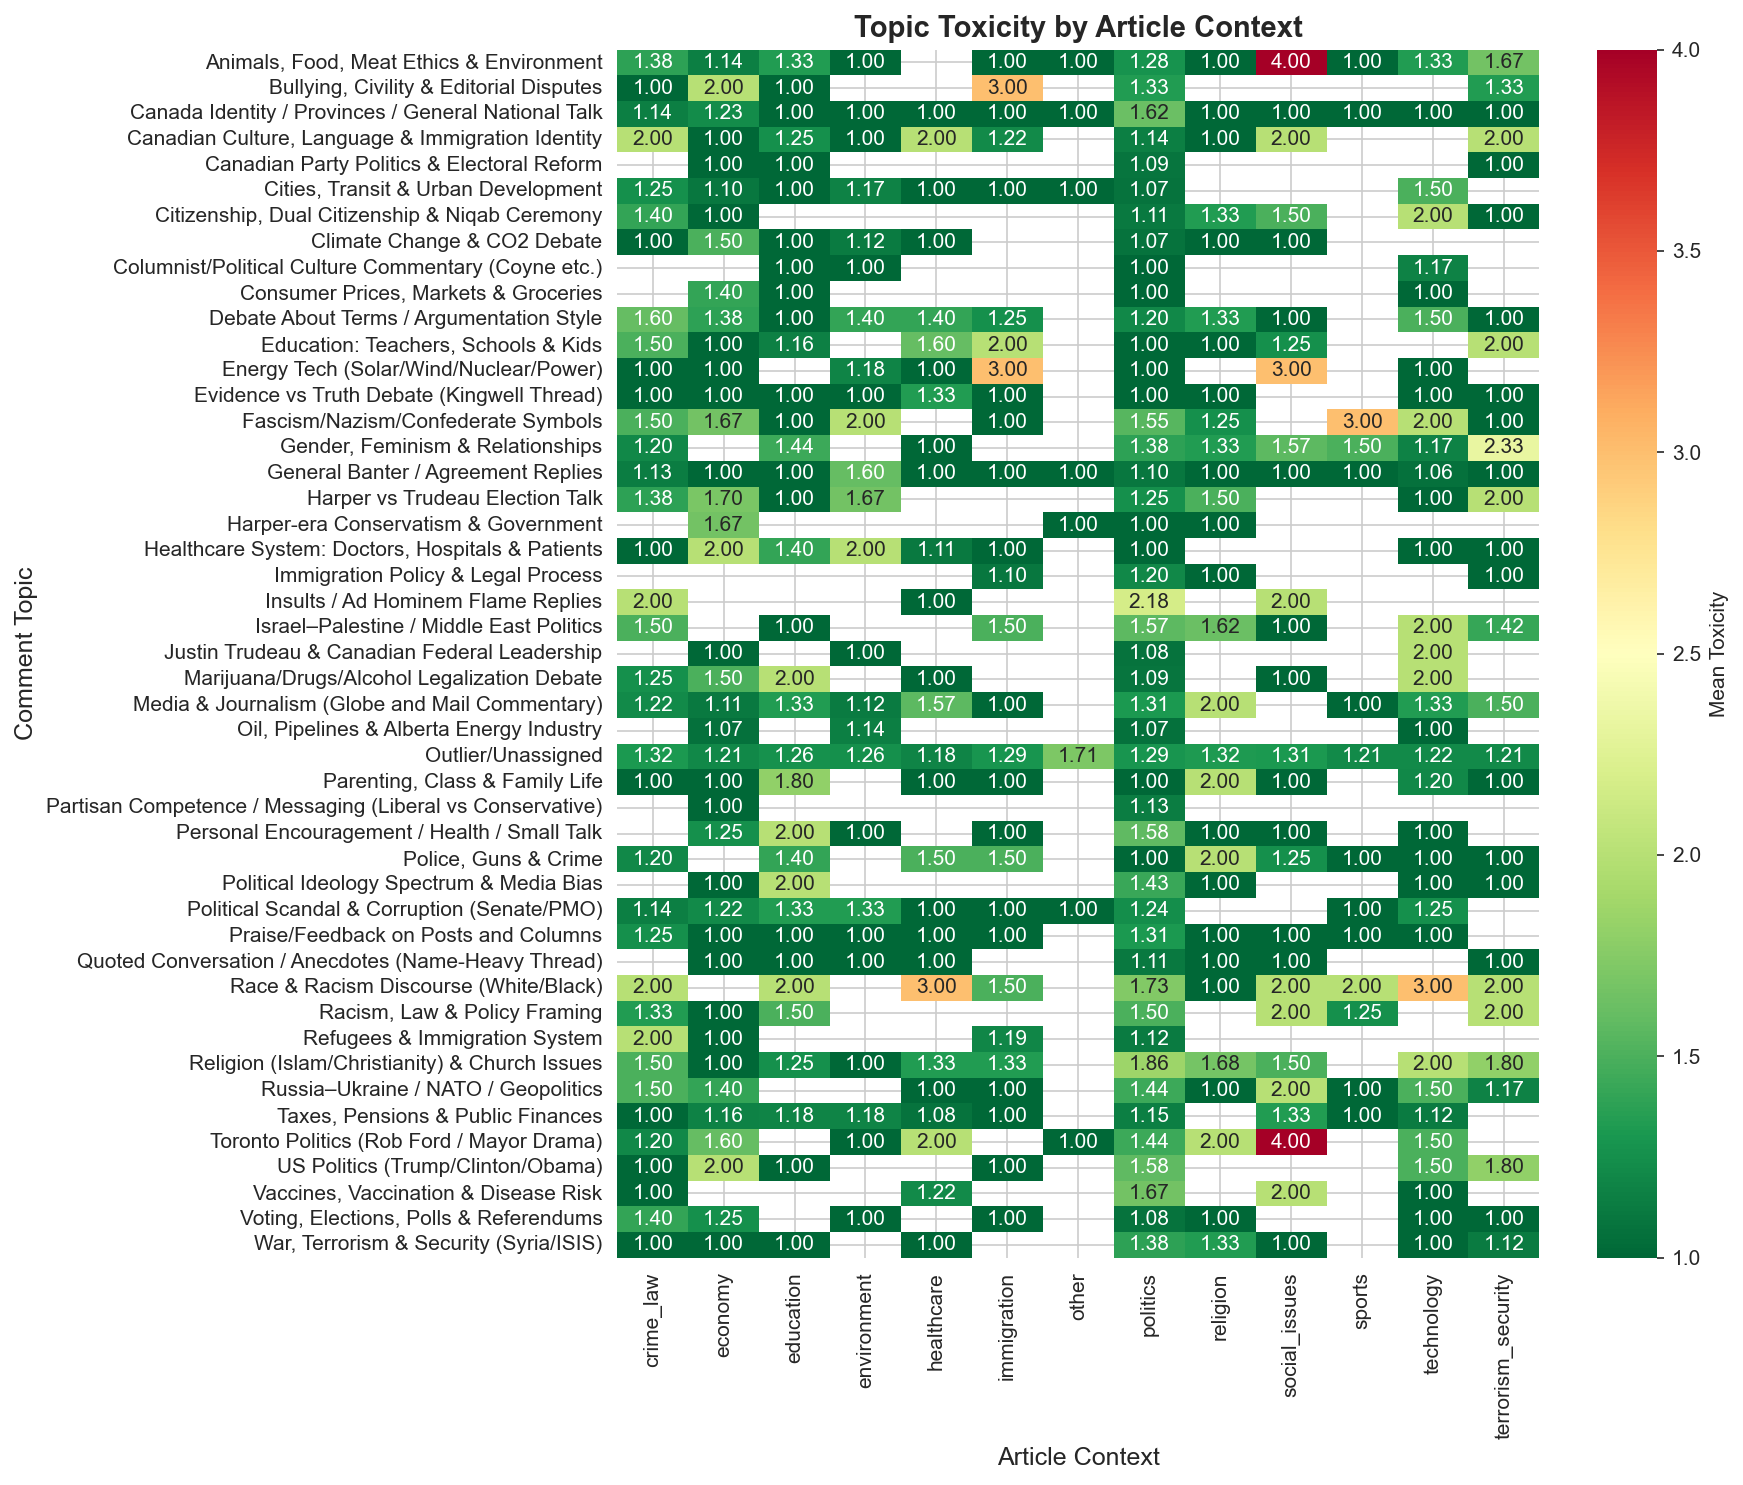

In [8]:
try:
    matrix = pd.read_csv('Output/phase7_topic_context_matrix.csv', index_col=0)
    
    print('Creating topic-context interaction heatmap...')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
                cbar_kws={'label': 'Mean Toxicity'})
    plt.title('Topic Toxicity by Article Context', fontsize=14, fontweight='bold')
    plt.xlabel('Article Context', fontsize=12)
    plt.ylabel('Comment Topic', fontsize=12)
    plt.tight_layout()
    plt.savefig('Output/figures/phase8_topic_context_heatmap.png', dpi=300, bbox_inches='tight')
    print('✓ SAVED: Output/figures/phase8_topic_context_heatmap.png')
    plt.show()
except:
    print('⚠️ Skipping context heatmap (phase7_topic_context_matrix.csv not found)')

---
## Visualization 6: Context Amplification Chart
---

Creating context amplification chart...
✓ SAVED: Output/figures/phase8_context_amplification.png


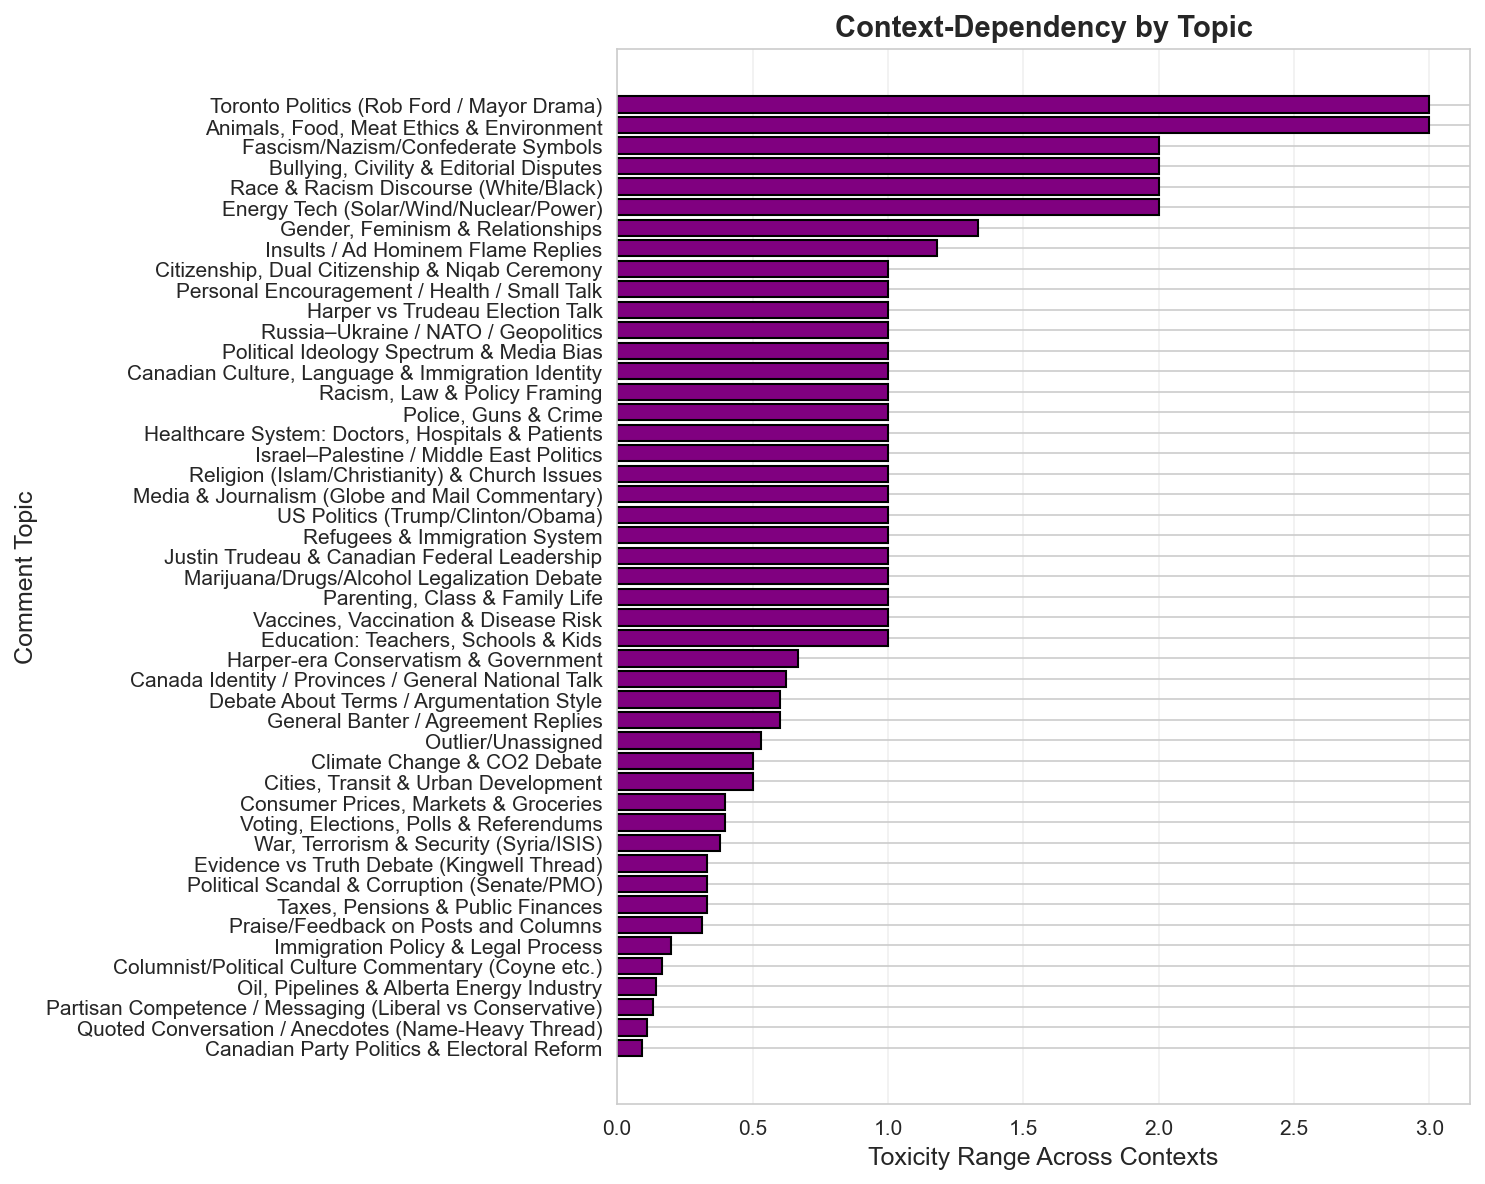

In [9]:
try:
    amplification = pd.read_csv('Output/phase7_context_amplification.csv')
    amplification = amplification.sort_values('amplification', ascending=True)
    
    print('Creating context amplification chart...')
    
    plt.figure(figsize=(10, 8))
    plt.barh(amplification['topic'], amplification['amplification'], 
             color='purple', edgecolor='black')
    plt.xlabel('Toxicity Range Across Contexts', fontsize=12)
    plt.ylabel('Comment Topic', fontsize=12)
    plt.title('Context-Dependency by Topic', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('Output/figures/phase8_context_amplification.png', dpi=300, bbox_inches='tight')
    print('✓ SAVED: Output/figures/phase8_context_amplification.png')
    plt.show()
except:
    print('⚠️ Skipping amplification chart (phase7_context_amplification.csv not found)')